# CODEx Single‑Sample Analysis Demo
This notebook demonstrates how to:
1. **Load** spatial CODEx datasets (UPMC, Charville, DFCI)
2. **Inspect** available cell‑type annotations
3. **Define** tumor centre mappings for feature extraction
4. **Run** the TIC single‑sample analysis pipeline
5. **Visualise** cross‑region causal effects with automatic pseudo‑time direction correction

> *Update the `EXP_ROOT` path to your own workspace before executing.*

In [17]:
import warnings, os, pickle, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

from tic.data import list_codex_datasets
from tic.data.loader import load_codex_dataset

# root directory to save experiment outputs
EXP_ROOT = "../tutorial/example_out/multi_regions"  # <-- EDIT ME

# enumerate available regions
upmc_regions      = list_codex_datasets(dataset='upmc')
charville_regions = list_codex_datasets(dataset='charville')
dfci_regions      = list_codex_datasets(dataset='dfci')

print(f"UPMC      regions: {len(upmc_regions)}")
print(f"Charville regions: {len(charville_regions)}")
print(f"DFCI      regions: {len(dfci_regions)}")


UPMC      regions: 308
Charville regions: 292
DFCI      regions: 58


In [18]:
# Load one example region per dataset to inspect cell types
upmc_example      = load_codex_dataset('upmc', region_id=upmc_regions[0])
charville_example = load_codex_dataset('charville', region_id=charville_regions[0])
dfci_example      = load_codex_dataset('dfci', region_id=dfci_regions[0])

def tumor_types(adata):
    cts = adata.obs['cell_type'].unique()
    return [ct for ct in cts if 'tumor' in ct.lower()]

print("Tumor cell types:")
print("  UPMC      :", tumor_types(upmc_example))
print("  Charville :", tumor_types(charville_example))
print("  DFCI      :", tumor_types(dfci_example))

# mapping used by FeatureWrapper
Tumor_Cell_Mapping = {
    "upmc": tumor_types(upmc_example),
    "charville": tumor_types(charville_example),
    "dfci": tumor_types(dfci_example),
}


Tumor cell types:
  UPMC      : ['Tumor (Ki67+)', 'Tumor (CD20+)', 'Tumor (CD21+)', 'Tumor (Podo+)', 'Tumor', 'Tumor (CD15+)']
  Charville : ['Tumor 2 (Ki67 Proliferating)', 'Tumor 3', 'Tumor 7', 'Tumor 4', 'Tumor 6 / DC', 'Tumor 1', 'Tumor 5']
  DFCI      : ['Tumor (PanCK hi)', 'Tumor (PanCK low)', 'Tumor (Ki67+)', 'Tumor (CD15+)']


In [19]:
print('gene names per dataset:')
print('UPMC     :', upmc_example.var_names.tolist())
print('Charville:', charville_example.var_names.tolist())
print('DFCI     :', dfci_example.var_names.tolist())


gene names per dataset:
UPMC     : ['CD11b', 'CD14', 'CD15', 'CD163', 'CD20', 'CD21', 'CD31', 'CD34', 'CD3e', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD68', 'CD8', 'CollagenIV', 'HLA-DR', 'Ki67', 'PanCK', 'Podoplanin', 'Vimentin', 'aSMA']
Charville: ['CD107a', 'CD117', 'CD11b', 'CD11c', 'CD134', 'CD14', 'CD15', 'CD163', 'CD20', 'CD21', 'CD31', 'CD38', 'CD3e', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD49f', 'CD68', 'CD8', 'CollagenIV', 'DAPI', 'FoxP3', 'Gal3', 'GranzymeB', 'HLA-DR', 'ICOS', 'Ki67', 'PD1', 'PDL1', 'PGP9.5', 'PanCK', 'Podoplanin', 'RORgammaT', 'S100A4', 'Siglec8', 'TFAM', 'TIM3', 'Vimentin', 'aSMA']
DFCI     : ['CD103', 'CD117', 'CD11b', 'CD11c', 'CD14', 'CD15', 'CD163', 'CD183', 'CD197', 'CD20', 'CD25', 'CD31', 'CD38', 'CD39', 'CD3e', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD56', 'CD68', 'CD69', 'CD8', 'DAPI', 'FoxP3', 'GranzymeB', 'GranzymeK', 'HLA-ABC', 'HLA-DR', 'ICOS', 'Ki67', 'LAG3', 'PD1', 'PDL1', 'PanCK', 'Perforin', 'Siglec8', 'TCF1', 'TCRgammadelta', 'TIM3', 'Vimentin']


## Single‑Sample Analysis Pipeline
We will compute:
1. **Cell‑type composition features** (`recipe='tme_default'`).
2. **Pseudotime** (`TIC.PseudotimeWrapper`).
3. **Biomarker trends** over pseudotime for EMT markers.
4. **Granger causality** of cell‑type predictors to target biomarkers.

Outputs are saved under `EXP_ROOT/<dataset>/<region_id>/`.

In [20]:
from pathlib import Path
from typing import List
from tqdm import tqdm
from tic.plotting.pseudotime import plot_biomarker_trends
from tic.wrappers.feature import FeatureWrapper
from tic.wrappers.pseudotime import PseudotimeWrapper
from tic.wrappers.causal import CausalWrapper
from utils.dataset.codex_upmc import UPMC_EMT_GENES

def single_sample_analysis(dataset: str, region_ids: List[str], out_dir: str, method: str = 'composition') -> None:
    """
    Run TIC single-sample workflow for multiple regions.
    For each region, extract features and perform single-sample analysis:
        1. Feature extraction
        2. Pseudotime inference
        3. Biomarker trend plotting
        4. Causal inference analysis
        5. Result saving

    Output structure:
    out_dir/
        region_id/
            biomarker_trends.png
            metrics.csv
            causal/
                biomarker/
                    bar.png
                    volcano.png
                    heatmap.png
                    results.pkl
    """
    os.makedirs(out_dir, exist_ok=True)

    for rid in tqdm(region_ids, desc=f'[{dataset}]'):
        adata  = load_codex_dataset(dataset=dataset, region_id=rid)
        genes  = set(adata.var_names)
        rdir   = os.path.join(out_dir, rid)
        os.makedirs(rdir, exist_ok=True)

        # Feature extraction
        fw = FeatureWrapper(
            recipe='tme_default',
            centre_types=Tumor_Cell_Mapping[dataset],
            graph_params={'method': 'voronoi'},
            subgraph_params={'strategy': 'radius', 'radius': 75},
        )
        fea_adata = fw.fit(adata)

        # Pseudotime inference
        ptw      = PseudotimeWrapper(rep_key=method, output_dir=rdir)
        pt_adata = ptw.fit(fea_adata)
        ptw.metrics.to_csv(os.path.join(rdir, 'metrics.csv'), index=False)

        # Biomarker trends
        plot_biomarker_trends(
            adata=pt_adata,
            selected_biomarkers=UPMC_EMT_GENES,
            x_transform='bin+normalize',
            y_transform='normalize',
            bins=100,
            save_path=os.path.join(rdir, 'biomarker_trends.png'),
        )

        # Causal inference
        causal_root = Path(rdir) / "causal"
        causal_root.mkdir(exist_ok=True)
        for biomarker in set(UPMC_EMT_GENES) & set(genes):
            dest = causal_root / biomarker
            dest.mkdir(exist_ok=True)

            cw = CausalWrapper(
                outcome=biomarker,
                include_extractors=('celltype_gene_count',),
                method='granger_causality',
                bins=100,
                method_kwargs={'maxlag': 3},
            )
            c_adata = cw.fit(pt_adata)
            cw.plot(c_adata, kind='bar',      save_path=dest/'bar.png')
            cw.plot(c_adata, kind='volcano',  save_path=dest/'volcano.png')
            cw.plot(c_adata, kind='heatmap',  save_path=dest/'heatmap.png')

            with open(dest/'results.pkl', 'wb') as fh:
                pickle.dump(cw.results, fh)


100%|██████████| 10/10 [00:04<00:00,  2.20it/s]


No statistically significant predictors found (p ≥ 0.050).
No statistically significant predictors found (p ≥ 0.050).
No statistically significant predictors found (p ≥ 0.050).


[upmc]:  50%|█████     | 1/2 [00:12<00:12, 12.98s/it]

No statistically significant predictors found (p ≥ 0.050).


2025-05-15 23:22:50,093 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


No statistically significant predictors found (p ≥ 0.050).
No statistically significant predictors found (p ≥ 0.050).
No statistically significant predictors found (p ≥ 0.050).


[upmc]: 100%|██████████| 2/2 [00:46<00:00, 23.03s/it]

No statistically significant predictors found (p ≥ 0.050).


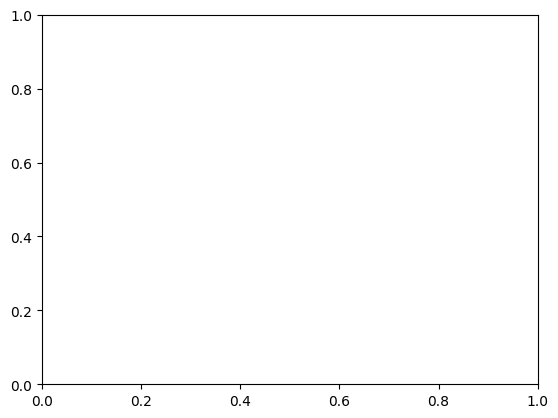

In [21]:
# >>> Uncomment to run a quick test on the first 2 UPMC regions
TEST_DIR = Path(EXP_ROOT) / 'EXP_UPMC_DEMO'
single_sample_analysis('upmc', upmc_regions[:2], str(TEST_DIR))


## Cross‑Region Causal Heatmap
To compare causal effects across regions while accounting for pseudo‑time direction (EMT vs MET), we use `plot_cross_region_causal_heatmap`. Specify `expected_sign` for the target biomarker:

* **E‑markers** → expected positive correlation
* **M‑markers** → expected negative correlation

In [22]:
from typing import Union, Literal, Optional, Dict
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

SignArg = Union[Literal['positive','pos','+'], Literal['negative','neg','-'], int]

def _to_sign(value: SignArg | None) -> Optional[int]:
    """Convert user-friendly sign spec to +1 / -1 / None."""
    if value is None:
        return None
    if isinstance(value, int):
        return 1 if value >= 0 else -1
    value = value.lower()
    if value in {"positive", "pos", "+"}:
        return 1
    if value in {"negative", "neg", "-"}:
        return -1
    raise ValueError(f"Unsupported expected_sign: {value}")


def plot_cross_region_causal_heatmap(
    out_dir: str | Path,
    region_ids: List[str],
    y_var: str,
    metric: Literal["max", "mean", "rms", "p_value"] = "max",
    p_threshold: float = 0.05,
    log2_transform: bool = True,
    expected_sign: SignArg | None = None,        # NEW
    top_n: int = 50,
    row_cluster: bool = True,
    col_cluster: bool = False,
    annot_sig: bool = False,
    figsize: tuple[int, int] = (12, 8),
    cmap: str = "coolwarm",
    save_path: Optional[str] = None,
) -> Optional[plt.Axes]:
    """
    Across-region heatmap of causal coefficients for a single Y biomarker.

    Parameters
    ----------
    expected_sign
        Expected direction of mono_correlation for *y_var*:
        positive / negative / + / - / 1 / -1.
        If actual sign (per-region metrics.csv) disagrees, the whole row
        (all X predictors) is multiplied by −1 before plotting.
        Default None → no auto-flip.
    """
    metric = metric.lower()
    if metric not in {"max", "mean", "rms", "p_value"}:
        raise ValueError("metric must be one of {'max', 'mean', 'rms', 'p_value'}")

    exp_sign = _to_sign(expected_sign)

    rows: Dict[str, Dict[str, float]] = {}
    sig_map: Dict[tuple[str, str], bool] = {}

    for rid in region_ids:
        region_dir = Path(out_dir) / rid
        pkl_path = region_dir / "causal" / y_var / "results.pkl"
        if not pkl_path.is_file():
            print(f"[WARN] Missing causal file: {pkl_path}")
            continue

        # 1) direction determination: read mono_correlation from metrics.csv
        flip = False
        if exp_sign is not None:
            metrics_csv = region_dir / "metrics.csv"
            if metrics_csv.is_file():
                mdf = pd.read_csv(metrics_csv)
                corr_row = mdf.loc[
                    (mdf["biomarker"] == y_var) & (mdf["mono_method"] == "spearman"),
                    "mono_correlation",
                ]
                if not corr_row.empty:
                    actual_sign = 0 if np.isclose(corr_row.iloc[0], 0) else np.sign(corr_row.iloc[0])
                    flip = actual_sign != 0 and actual_sign != exp_sign
            else:
                print(f"[WARN] metrics.csv missing for {rid}; skip sign check.")

        # 2) collect causal results
        with pkl_path.open("rb") as f:
            results: Dict[str, dict] = pickle.load(f)

        vals: Dict[str, float] = {}
        for predictor, stats in results.items():
            p_adj = stats["p_value"]
            sig = p_adj <= p_threshold
            sig_map[(rid, predictor)] = sig
            if not sig:
                continue

            if metric == "p_value":
                val = -np.log10(p_adj + 1e-12)
            else:
                coeffs = np.asarray(stats["best_model_parameters"], dtype=float)
                if metric == "max":
                    val = coeffs[np.argmax(np.abs(coeffs))]
                elif metric == "mean":
                    val = float(np.nanmean(coeffs))
                else:  # rms
                    rms = np.sqrt(np.nanmean(coeffs**2))
                    val = np.sign(np.nanmean(coeffs)) * rms
                if log2_transform:
                    val = np.sign(val) * np.log2(np.abs(val) + 1e-12)

            vals[predictor] = float(val)

        if flip:
            vals = {k: -v for k, v in vals.items()}
            print(f"[INFO] Direction flipped for region {rid}")

        if vals:
            rows[rid] = vals

    if not rows:
        print("No significant predictors found.")
        return None

    # ---------- DataFrame  ----------
    df = (
        pd.DataFrame.from_dict(rows, orient="index")
        .sort_index()
        .reindex(sorted({k for d in rows.values() for k in d}), axis=1)
    )
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)

    if top_n is not None and df.shape[1] > top_n:
        abs_rank = df.abs().max(axis=0).sort_values(ascending=False)
        df = df.loc[:, abs_rank.index[:top_n]]

    df.fillna(0.0, inplace=True)

    # ---------- Plot ----------
    sns.set_theme(style="white")
    vmax = np.nanpercentile(np.abs(df.values), 99)

    if df.shape[0] < 2 or df.shape[1] < 2:
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(
            df,
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
            linewidths=0.4,
            cbar_kws={
                "label": "-log10(adj p)"
                if metric == "p_value"
                else f"{metric} ({'log2' if log2_transform and metric != 'p_value' else 'raw'})"
            },
            ax=ax,
        )
    else:
        cg = sns.clustermap(
            df,
            row_cluster=row_cluster,
            col_cluster=col_cluster,
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
            linewidths=0.3,
            figsize=figsize,
            cbar_kws={
                "label": "-log10(adj p)"
                if metric == "p_value"
                else f"{metric} ({'log2' if log2_transform and metric != 'p_value' else 'raw'})"
            },
            xticklabels=True,
            yticklabels=True,
        )
        ax = cg.ax_heatmap

    ax.set_xlabel("Predictor (X variable)", fontsize=10)
    ax.set_ylabel("Region", fontsize=10)
    for tick in ax.get_xticklabels():
        tick.set_rotation(90)
        tick.set_fontsize(6)
    ax.set_title(
        f"Causal effect on '{y_var}' "
        f"(metric: {metric}, p ≤ {p_threshold})",
        pad=60,
    )

    if annot_sig and metric != "p_value":
        for y, region in enumerate(df.index):
            for x, predictor in enumerate(df.columns):
                if sig_map.get((region, predictor), False):
                    ax.text(
                        x + 0.5,
                        y + 0.5,
                        "*",
                        ha="center",
                        va="center",
                        color="black",
                        fontsize=6,
                    )

    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300)
        plt.close()
        return None

    return ax


In [23]:
# >>> Example (after analysis is done)
plot_cross_region_causal_heatmap(
    out_dir=TEST_DIR,
    region_ids=upmc_regions[:2],
    y_var='PanCK',
    expected_sign='negative',   # PanCK expected to decrease along EMT
    metric='rms',
    log2_transform=False,
    save_path=str(TEST_DIR/'PanCK_heatmap.png'),
)


[INFO] Direction flipped for region UPMC_c001_v001_r001_reg001
[INFO] Direction flipped for region UPMC_c001_v001_r001_reg002
